<a href="https://colab.research.google.com/github/Shloka-16/deepfake-detection/blob/data-visualizations/deepfake_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
pip install kagglehub

In [ ]:
from google.colab import userdata

kaggle_api = userdata.get("KAGGLE_KEY")

In [ ]:
mkdir -p ~/.kaggle && echo kaggle_api > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d "xhlulu/140k-real-and-fake-faces" --unzip

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
Resuming from 2409627648 bytes (1614928070 bytes left)...
100% 3.75G/3.75G [00:07<00:00, 229MB/s]



In [ ]:
import os

for root, dirs, files in os.walk("/content/real_vs_fake"):
    print(root, "->", len(files), "files")

/content/real_vs_fake -> 0 files
/content/real_vs_fake/real-vs-fake -> 0 files
/content/real_vs_fake/real-vs-fake/train -> 0 files
/content/real_vs_fake/real-vs-fake/train/real -> 50000 files
/content/real_vs_fake/real-vs-fake/train/fake -> 50000 files
/content/real_vs_fake/real-vs-fake/valid -> 0 files
/content/real_vs_fake/real-vs-fake/valid/real -> 10000 files
/content/real_vs_fake/real-vs-fake/valid/fake -> 10000 files
/content/real_vs_fake/real-vs-fake/test -> 0 files
/content/real_vs_fake/real-vs-fake/test/real -> 10000 files
/content/real_vs_fake/real-vs-fake/test/fake -> 10000 files


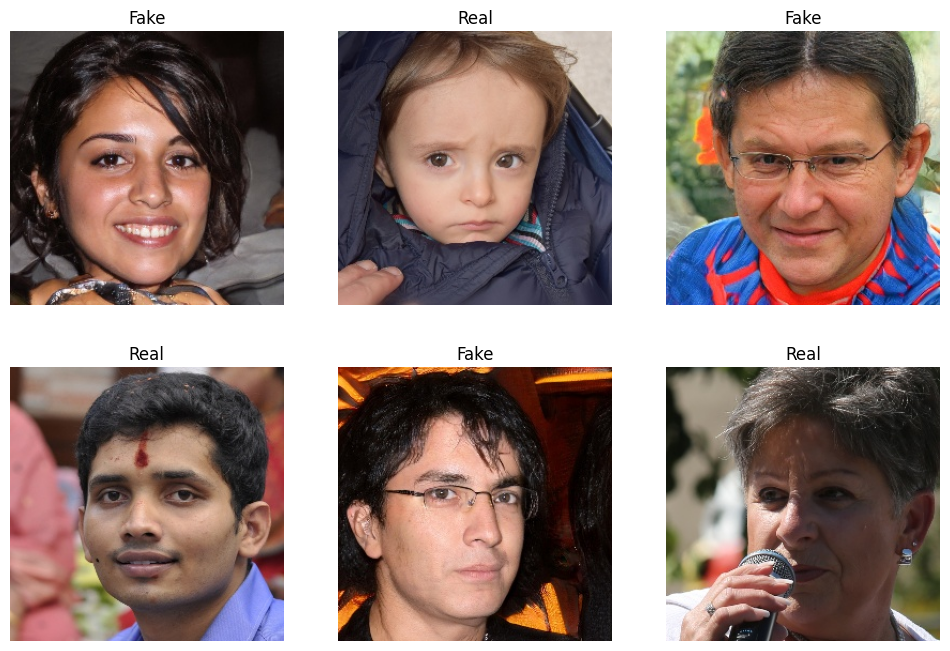

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Get all training images
real_images = glob.glob("/content/real_vs_fake/real-vs-fake/train/real/*")
fake_images = glob.glob("/content/real_vs_fake/real-vs-fake/train/fake/*")

# Pick random samples
sample_real = random.sample(real_images, 3)
sample_fake = random.sample(fake_images, 3)

samples = sample_real + sample_fake
random.shuffle(samples)

plt.figure(figsize=(12, 8))

for i, path in enumerate(samples):
    img = Image.open(path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

    label = "Real" if "/real/" in path else "Fake"
    plt.title(label)

plt.show()

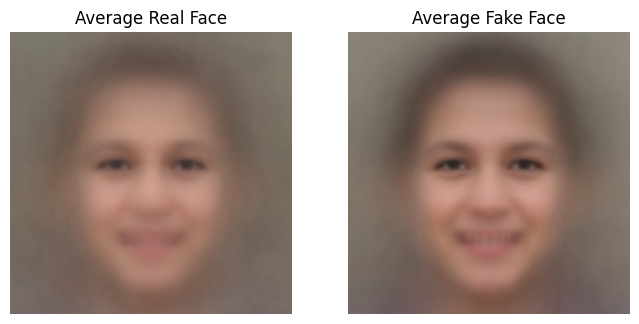

In [ ]:
import numpy as np

def average_image(paths, n=500):
    imgs=[]

    for path in random.sample(paths,n):
        img = Image.open(path).resize((256,256))
        imgs.append(np.array(img))

    return np.mean(imgs,axis=0).astype(np.uint8)


avg_real = average_image(real_images)
avg_fake = average_image(fake_images)


plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(avg_real)
plt.axis("off")
plt.title("Average Real Face")


plt.subplot(1,2,2)
plt.imshow(avg_fake)
plt.axis("off")
plt.title("Average Fake Face")

plt.show()

In [ ]:
import numpy as np

def average_brightness(paths, n=1000):
    values = []

    for path in random.sample(paths,n):
        img = Image.open(path).convert("RGB")
        arr = np.array(img)

        values.append(arr.mean())

    return values


real_brightness = average_brightness(real_images)
fake_brightness = average_brightness(fake_images)

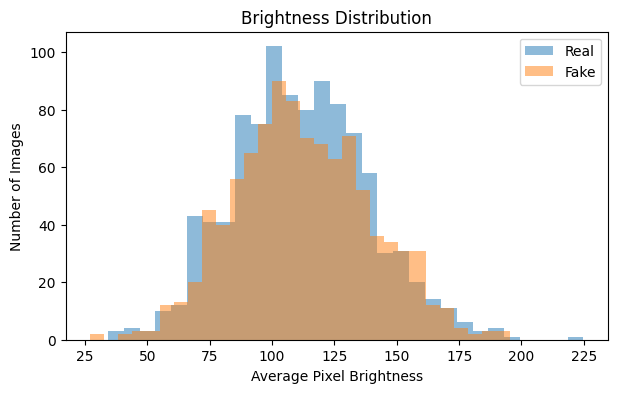

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(
    real_brightness,
    bins=30,
    alpha=0.5,
    label="Real"
)

plt.hist(
    fake_brightness,
    bins=30,
    alpha=0.5,
    label="Fake"
)

plt.xlabel("Average Pixel Brightness")
plt.ylabel("Number of Images")
plt.title("Brightness Distribution")
plt.legend()
plt.show()

In [ ]:
import random
import glob

# Correct paths
real_images = glob.glob(
    "/content/real_vs_fake/real-vs-fake/train/real/*"
)

fake_images = glob.glob(
    "/content/real_vs_fake/real-vs-fake/train/fake/*"
)

print("Real images:", len(real_images))
print("Fake images:", len(fake_images))

# Sample 1000 from each
real_sample = random.sample(real_images, 1000)
fake_sample = random.sample(fake_images, 1000)

image_paths = real_sample + fake_sample

labels = (
    ["Real"] * 1000 +
    ["Fake"] * 1000
)

print("Total samples:", len(image_paths))

Real images: 50000
Fake images: 50000
Total samples: 2000


In [ ]:
from PIL import Image
import numpy as np


def load_images(paths):
    data=[]

    for path in paths:
        img = Image.open(path)

        # resize smaller for PCA
        img = img.resize((64,64))

        # convert to numpy
        img = np.array(img)

        # flatten:
        # (64,64,3) → (12288,)
        img = img.flatten()

        data.append(img)

    return np.array(data)


X = load_images(image_paths)

print(X.shape)

(2000, 12288)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(2000, 2)


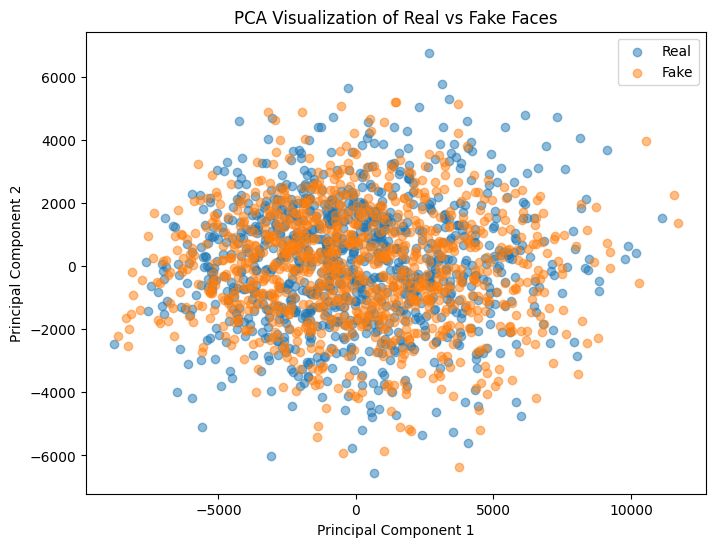

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))

for label, color in [("Real","blue"), ("Fake","red")]:

    indices = [
        i for i,x in enumerate(labels)
        if x == label
    ]

    plt.scatter(
        X_pca[indices,0],
        X_pca[indices,1],
        label=label,
        alpha=0.5
    )


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Real vs Fake Faces")
plt.legend()
plt.show()